In [1]:
import torch
import matplotlib.pyplot as plt

## Data Preparation

In [ ]:
import requests
import zipfile
from pathlib import Path

# Unzip the dataset 
data_path = "data"
unzipped_data_path = "magnetic-tile-surface-defects.zip"
# Unzip pizza, steak, sushi data
with zipfile.ZipFile(unzipped_data_path, "r") as zip_ref:
    print("Unzipping Magnetic Dataset")
    zip_ref.extractall(data_path)

Unzipping Magnetic Dataset


In [ ]:
# 1. Prepare the dataset for trainig -> convert to YOLO format



import torch
import shutil
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path
from PIL import Image
from scipy.ndimage import label as cc_label
from torchvision.ops import masks_to_boxes

# Setup path to data folder with mask labels
data_path_mask = Path("data/")

# Setup path to data folder with bounidng box labels
data_path_box = Path("dataset/")

# Setup train, validation and testing paths
train_dir = data_path_box / "train"
validation_dir = data_path_box / "val"
test_dir = data_path_box / "test"

# Set 3 paths into a list
dirs_to_check = [train_dir, validation_dir, test_dir]

# Check if dir exists, if not create one
for d in dirs_to_check:
    if d.is_dir():
        print(f"{d} directory exists.")
    else:
        print(f"{d} directory does not exist. Creating it now.")
        d.mkdir(parents=True, exist_ok=True)

# Check if images/labels dir are available, if not create them
for split_dir in dirs_to_check:
    images_dir = split_dir / "images"
    labels_dir = split_dir / "labels"

    # Check img path
    if not images_dir.is_dir():
        print(f"{images_dir} directory does not exist. Creating it now.")
        images_dir.mkdir(parents=True, exist_ok=True)
    
    # Check label path
    if not labels_dir.is_dir():
        print(f"{labels_dir} directory does not exist. Creating it now.")
        labels_dir.mkdir(parents=True, exist_ok=True)


## Transform mask labels into bounding box labels ##
out_labels_dir = Path("dataset_work/labels")
if not out_labels_dir.is_dir():
    print(f"{out_labels_dir} directory does not exist. Creating it now.")
    out_labels_dir.mkdir(parents=True, exist_ok=True)

out_images_dir = Path("dataset_work/images")
if not out_images_dir.is_dir():
    print(f"{out_images_dir} directory does not exist. Creating it now.")
    out_images_dir.mkdir(parents=True, exist_ok=True)


class_dirs = sorted(data_path_mask.iterdir())

for class_id, class_dir in enumerate(class_dirs):
    imgs_dir = class_dir / "Imgs"
    for mask_path in imgs_dir.glob("*.PNG"):
        base = mask_path.stem
        img_name = base + ".jpg"
        img_path = imgs_dir / img_name
        # Put image into images folder
        shutil.copy(img_path, out_images_dir)

        # Load mask
        mask = Image.open(mask_path)
        mask_arr = np.array(mask)
        h, w = mask_arr.shape


        bin_mask = (mask_arr > 0).astype(np.uint8)
        labeled, num_components = cc_label(bin_mask)  
        if num_components == 0:
            # Keine Objekte: leere Label-Datei anlegen
            label_path = out_labels_dir / f"{base}.txt"  # Datei existiert, aber ohne Inhalt
            
            # Just save class id of the img without any labels
            open(label_path, "a").close()
            continue

        masks_list = []
        for comp_id in range(1, num_components + 1):
            comp_mask = (labeled == comp_id).astype(np.uint8)
            masks_list.append(comp_mask)


        masks_tensor = torch.from_numpy(np.stack(masks_list, axis=0))
        boxes = masks_to_boxes(masks_tensor)

        label_path = out_labels_dir / f"{base}.txt"
        with open(label_path, "w") as f:
            for box in boxes:
                x_min, y_min, x_max, y_max = box.tolist()

                # In YOLO-Format (relativ zu Breite/Höhe)
                x_center = (x_min + x_max) / 2.0 / w
                y_center = (y_min + y_max) / 2.0 / h
                bw = (x_max - x_min) / w
                bh = (y_max - y_min) / h

                f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {bw:.6f} {bh:.6f}\n")
        

dataset\train directory does not exist. Creating it now.
dataset\val directory does not exist. Creating it now.
dataset\test directory does not exist. Creating it now.
dataset\train\images directory does not exist. Creating it now.
dataset\train\labels directory does not exist. Creating it now.
dataset\val\images directory does not exist. Creating it now.
dataset\val\labels directory does not exist. Creating it now.
dataset\test\images directory does not exist. Creating it now.
dataset\test\labels directory does not exist. Creating it now.


In [ ]:
free = data_path_mask / "zMT_Free" / "Imgs"

# Check the length of images without defect
len(list(free.iterdir()))

1904

In [ ]:
# Check the length of all labels 
len(list(out_labels_dir.iterdir()))

1344

## Visualizing the bounding boxes

Anzahl Labels mit Defekt: 388
Zeige diese Labels:
  exp1_num_36290.txt
  exp4_num_135615.txt
  exp5_num_284552.txt
  exp5_num_149023.txt
  exp3_num_249637.txt


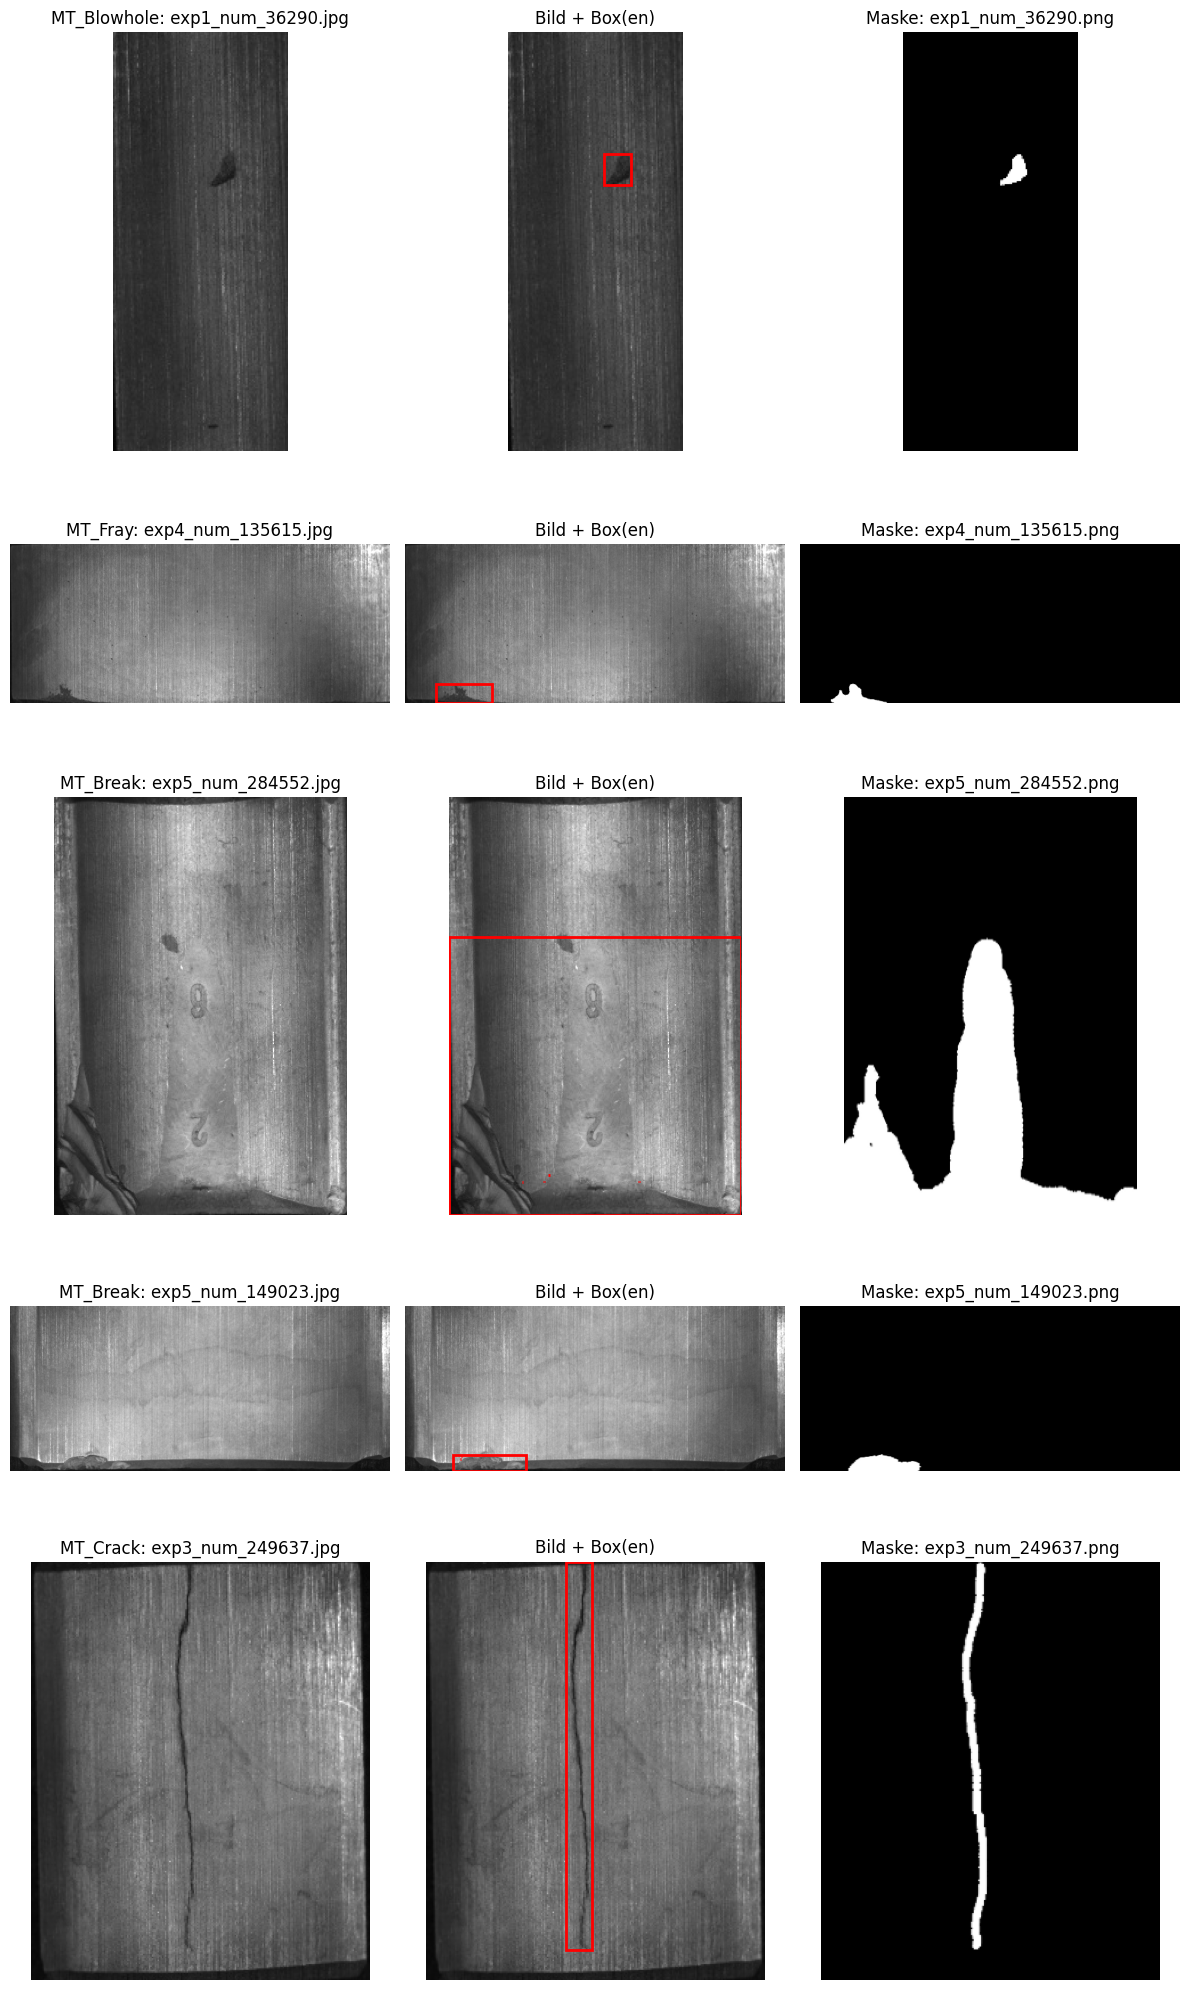

In [ ]:
import random
from pathlib import Path
%matplotlib inline
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

labels_dir = Path("dataset_work/labels")
images_root = Path("data")   

# 5 defect classes
class_dirs = ["MT_Blowhole", "MT_Break", "MT_Crack",
              "MT_Fray", "MT_Uneven"]

def find_image_and_mask(base):
    """Suche JPG und PNG in den 5 Defekt-Klassen."""
    for cls in class_dirs:
        imgs_dir = images_root / cls / "Imgs"
        jpg_path = imgs_dir / f"{base}.jpg"
        png_path = imgs_dir / f"{base}.png"
        if jpg_path.is_file() and png_path.is_file():
            return jpg_path, png_path, cls
    return None, None, None


all_labels = [p for p in labels_dir.glob("*.txt") if p.stat().st_size > 0]
print("Anzahl Labels mit Defekt:", len(all_labels))

n_samples = min(5, len(all_labels))
samples = random.sample(all_labels, k=n_samples)
print("Zeige diese Labels:")
for lf in samples:
    print(" ", lf.name)

# 2) Plot
fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))
if n_samples == 1:
    axes = np.array([axes])

for i, label_path in enumerate(samples):
    base = label_path.stem

    jpg_path, png_path, cls = find_image_and_mask(base)
    if jpg_path is None:
        print(f"Kein Bild/keine Maske gefunden für {base}")
        continue

    img = Image.open(jpg_path).convert("RGB")
    img_arr = np.array(img)
    mask = Image.open(png_path).convert("L")
    mask_arr = np.array(mask)
    h, w, _ = img_arr.shape

    # YOLO-Label -> Bounding box
    boxes = []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id, xc, yc, bw, bh = parts
            xc, yc, bw, bh = map(float, (xc, yc, bw, bh))
            x_min = (xc - bw / 2.0) * w
            x_max = (xc + bw / 2.0) * w
            y_min = (yc - bh / 2.0) * h
            y_max = (yc + bh / 2.0) * h
            boxes.append((x_min, y_min, x_max, y_max))

    # 1) Original img
    ax0 = axes[i, 0]
    ax0.imshow(img_arr)
    ax0.set_title(f"{cls}: {jpg_path.name}")
    ax0.axis("off")

    # 2) img + bounding box
    ax1 = axes[i, 1]
    ax1.imshow(img_arr)
    ax1.set_title("Bild + Box(en)")
    ax1.axis("off")
    for (x_min, y_min, x_max, y_max) in boxes:
        rect = patches.Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax1.add_patch(rect)

    # 3) Masks
    ax2 = axes[i, 2]
    ax2.imshow(mask_arr, cmap="gray")
    ax2.set_title(f"Maske: {png_path.name}")
    ax2.axis("off")

plt.tight_layout()
plt.show()

### Spliting the labels into training, validation and testing 

In [ ]:
# 2. Split the dataset

import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path
import pandas as pd

# Src folders
base_dir = Path("dataset_work") 
images_dir = base_dir / "images"
labels_dir = base_dir / "labels"

# End folders 
train_dir = Path("dataset/train")
val_dir   = Path("dataset/val")
test_dir  = Path("dataset/test")


# Collect all images and extract the file names
all_images = sorted(images_dir.glob("*.jpg"))
data_names = [name.stem for name in all_images] 

# Use pandas to group all names
df = pd.DataFrame(data_names, columns=["data_name"])

# Function for getting the class_id for surface without defect class_id = 4
def get_first_class(name):
    label_path = labels_dir / f"{name}.txt"
    with open(label_path, 'r') as f:
        first_line = f.readline()
        if first_line:
            return first_line.split()[0] 
    return "5"

df['label'] = df['data_name'].apply(get_first_class)


# Split data 
train_df, rest_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=df['label']
)

val_df, test_df = train_test_split(
    rest_df,
    test_size=0.5,
    random_state=42,
    stratify=rest_df['label']
)


In [199]:
val_df

,data_name,label
798,exp4_num_309692,5
1073,exp5_num_36269,0
1212,exp6_num_274218,4
839,exp4_num_351088,5
385,exp2_num_338872,5
...,...,...
1032,exp5_num_317612,5
1244,exp6_num_306696,5
103,exp1_num_282886,5
497,exp3_num_187556,5


### Copy splitted data into target folders

In [ ]:
# 3. Copy everything to their place
import shutil
import pandas as pd

target_dic = [
    train_df['data_name'],
    val_df['data_name'],
    test_df['data_name']
]

# Iterate through pandas DataFrame
for i, names in enumerate(target_dic):

    # Check the target_dir using i
    if i == 0:
        target_dir = train_dir
    elif i == 1:
        target_dir = val_dir
    else:
        target_dir = test_dir

    for name in names.values:
        img_path = images_dir / f"{name}.jpg"
        shutil.copy(img_path, target_dir/"images")

        label_path = labels_dir / f"{name}.txt"
        shutil.copy(label_path, target_dir/"labels")

In [210]:
# Create yaml file for dataset
import yaml

# Define the dataset structure
dataset_info = {
    "train": "dataset/train",
    "val": "dataset/val",
    "test": "dataset/test",
    "nc": 5,  # Number of classes
    "names": {0: "Blowhole", 
              1: "Break", 
              2: "Crack", 
              3: "Fray",  
              4: "Uneven"}  # Class index mapped to name
}

yaml_file = "dataset.yaml"

# Save 
with open('magnetic_tiles.yaml', 'w') as f:
    yaml.dump(dataset_info, f, default_flow_style=False)

In [ ]:
# Zip the set for downloading and prepare for training on kaggle

import requests
import zipfile
from pathlib import Path

# Unzip the dataset into data folder
src_dir = "dataset"
output_file_name = "magnetic_tiles_dataset"
# Zip dataset for kaggle 
shutil.make_archive(output_file_name, 'zip', src_dir)

'c:\\Users\\hggda\\Documents\\KIT\\HiWi_IMI\\PyTorch_git\\pytorch-learning\\07_final_project\\magnetic_tiles_dataset.zip'


### Train model

In [ ]:
from ultralytics import RTDETR

# Load a COCO-pretrained RT-DETR-l model
model = RTDETR("rtdetr-l.pt")

# Display model information (optional)
model.info()

# # Train the model on the COCO8 example dataset for 100 epochs
# results = model.train(data="coco8.yaml", epochs=100, imgsz=640)

# # Run inference with the RT-DETR-l model on the 'bus.jpg' image
# results = model("path/to/bus.jpg")

rt-detr-l summary: 449 layers, 32,970,476 parameters, 0 gradients, 108.3 GFLOPs


(449, 32970476, 0, 108.3437056)

In [3]:
import kagglehub
kagglehub.login()

In [ ]:
import torchinfo
from torchinfo import summary
summary(model=model.model,
        input_size=(1, 3, 640, 640),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=30,
        depth=10,
        row_settings=["var_names"])




Layer (type (var_name))                                           Input Shape                    Output Shape                   Param #                        Trainable
DetectionModel (DetectionModel)                                   [1, 3, 640, 640]               [1, 300, 84]                   --                             False
├─Sequential (model)                                              --                             --                             --                             False
│    └─HGStem (0)                                                 [1, 3, 640, 640]               [1, 48, 160, 160]              --                             False
│    │    └─Conv (stem1)                                          [1, 3, 640, 640]               [1, 32, 320, 320]              --                             False
│    │    │    └─Conv2d (conv)                                    [1, 3, 640, 640]               [1, 32, 320, 320]              (864)                          False
│    │

## Evaluating the model

Found images with defects (Classes 0-4): 39


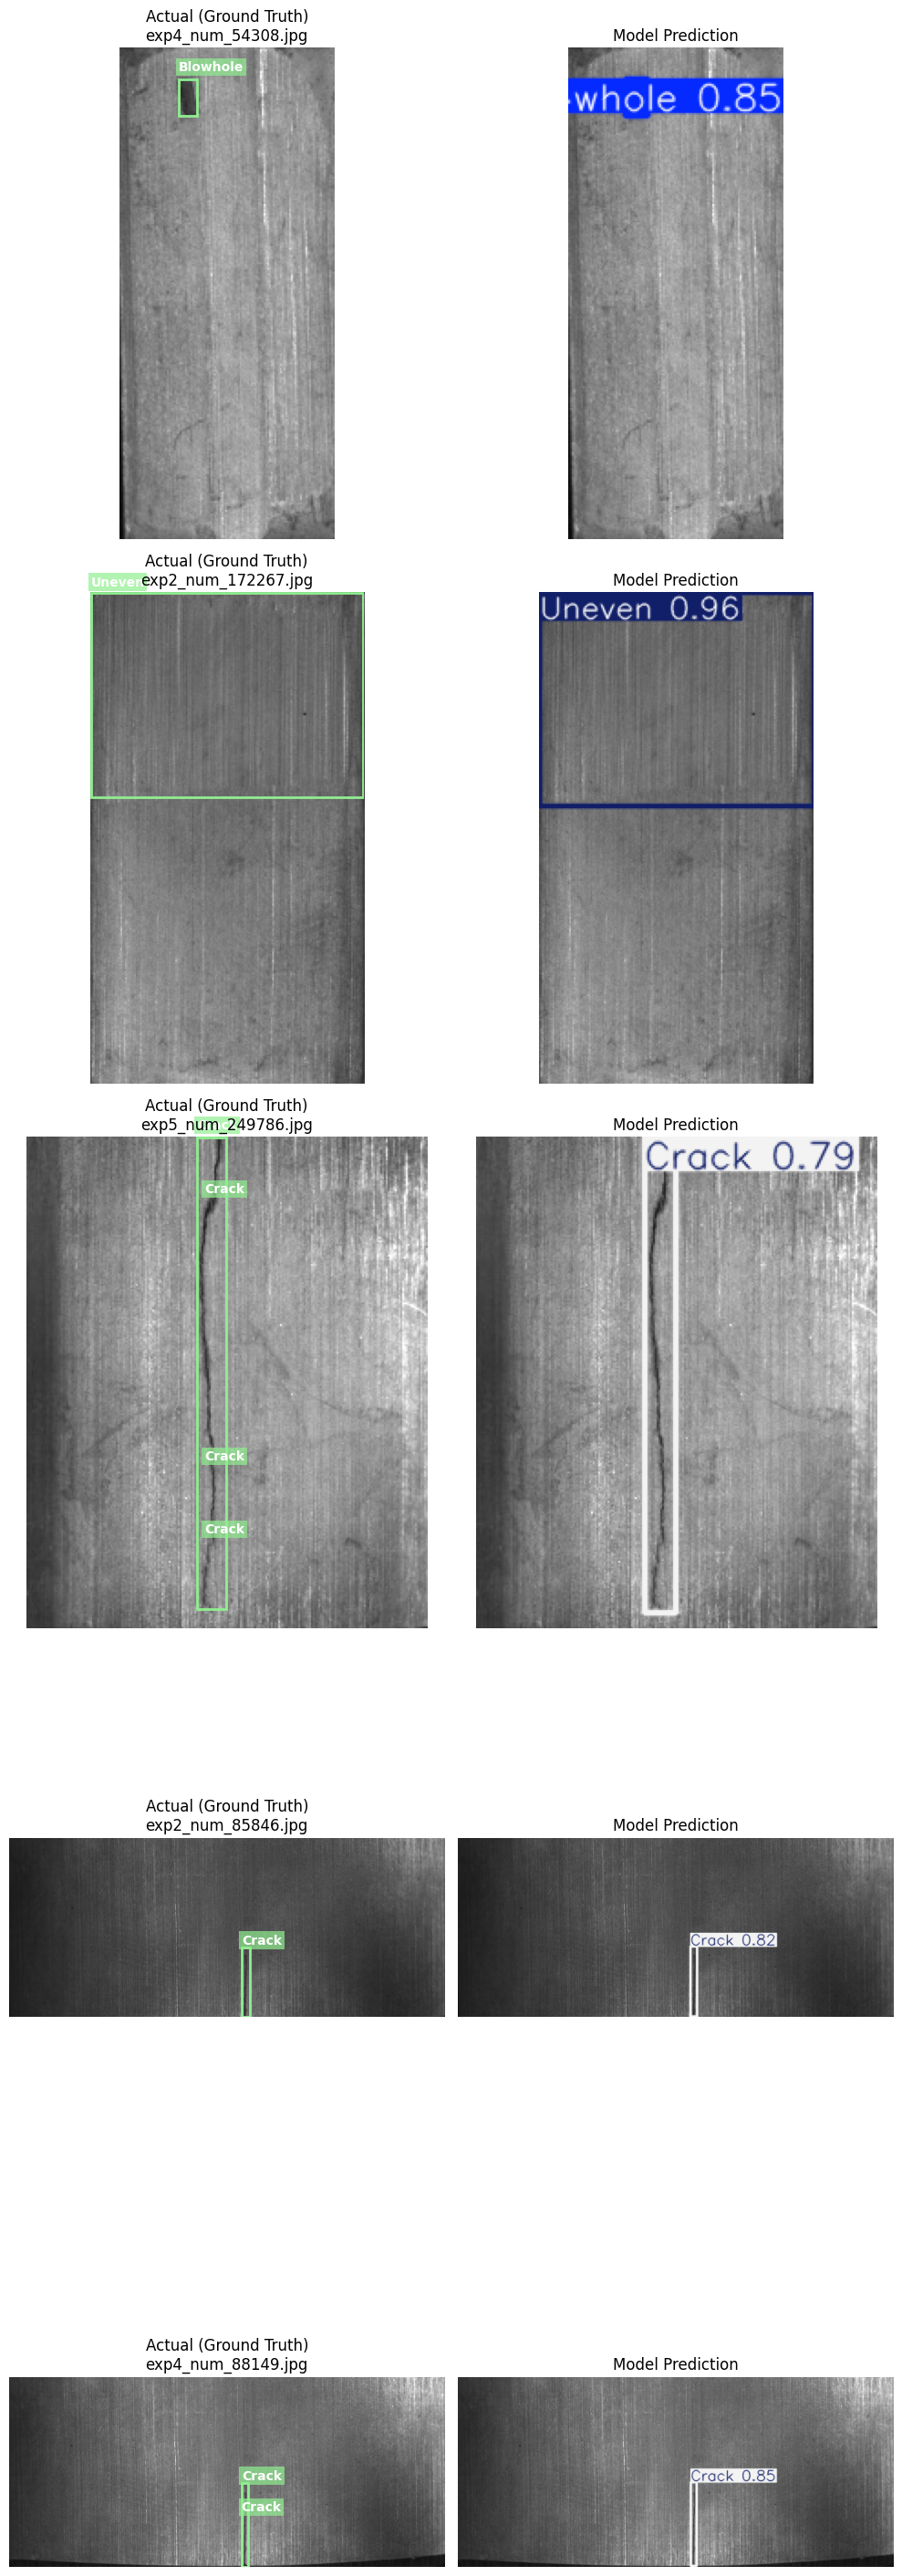

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import random
from pathlib import Path

def plot_evaluation(model, images_dir, labels_dir, class_names, num_samples=5):
    """
    Plots Ground Truth vs. Model Prediction only for images with defects (classes 0-4).
    Ensures correct RGB color representation.
    """
    # 1. Search and filter images
    img_paths = sorted(list(Path(images_dir).glob("*.jpg"))) # Adjust extension if needed (e.g., *.png)
    valid_images = []

    # Filter images to find only those with relevant classes (0-4)
    for img_path in img_paths:
        label_path = Path(labels_dir) / f"{img_path.stem}.txt"
        
        # Skip if label file does not exist
        if not label_path.exists():
            continue
            
        with open(label_path, "r") as f:
            lines = f.readlines()
            
        # Criteria 1: Ignore images without defects (empty files)
        if not lines:
            continue
            
        # Criteria 2: Check if image contains classes 0-4
        contains_relevant_class = False
        for line in lines:
            try:
                cls_id = int(line.split()[0])
                if 0 <= cls_id <= 4:
                    contains_relevant_class = True
                    break
            except ValueError:
                continue
        
        if contains_relevant_class:
            valid_images.append(img_path)

    print(f"Found images with defects (Classes 0-4): {len(valid_images)}")

    # 2. Select random samples
    if not valid_images:
        print("No matching images found.")
        return

    # Select random images or all if fewer than num_samples
    if len(valid_images) > num_samples:
        selected_images = random.sample(valid_images, num_samples)
    else:
        selected_images = valid_images

    # 3. Plotting
    # Create subplots
    fig, axes = plt.subplots(len(selected_images), 2, figsize=(10, 6 * len(selected_images)))
    if len(selected_images) == 1: axes = [axes] # Handle single image case

    for i, img_path in enumerate(selected_images):
        # Open image using PIL (Native RGB)
        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        label_path = Path(labels_dir) / f"{img_path.stem}.txt"

        # --- Left Side: Ground Truth (Actual) ---
        ax_gt = axes[i][0] if len(selected_images) > 1 else axes[0]
        ax_gt.imshow(img)
        ax_gt.set_title(f"Actual (Ground Truth)\n{img_path.name}", fontsize=12)
        ax_gt.axis("off")

        if label_path.exists():
            with open(label_path, "r") as f:
                lines = f.readlines()
                for line in lines:
                    data = list(map(float, line.split()))
                    cls_id = int(data[0])
                    
                    # Only draw classes 0-4
                    if cls_id not in range(5): continue

                    xc, yc, bw, bh = data[1], data[2], data[3], data[4]
                    
                    # Convert YOLO format (normalized) to Pixel coordinates
                    x1 = (xc - bw / 2) * w
                    y1 = (yc - bh / 2) * h
                    box_w = bw * w
                    box_h = bh * h

                    # Draw Rectangle
                    rect = patches.Rectangle(
                        (x1, y1), box_w, box_h,
                        linewidth=2, edgecolor="lightgreen", facecolor="none"
                    )
                    ax_gt.add_patch(rect)

                    # Add Label Text with background (similar to YOLO style)
                    label_text = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
                    
                    ax_gt.text(
                        x1, y1 - 5, label_text, 
                        color='white', fontsize=10, fontweight='bold',
                        bbox=dict(facecolor='lightgreen', edgecolor='none', alpha=0.7, pad=2)
                    )

        # --- Right Side: Model Prediction ---
        ax_pred = axes[i][1] if len(selected_images) > 1 else axes[1]
        
        # Run inference
        results = model(str(img_path), verbose=False)[0]
        
        # results.plot() returns a numpy array in BGR format -> Convert to RGB
        # [..., ::-1] reverses the last dimension (channels) from BGR to RGB
        res_plotted = results.plot()
        res_rgb = res_plotted[..., ::-1] 
        
        ax_pred.imshow(res_rgb)
        ax_pred.set_title("Model Prediction", fontsize=12)
        ax_pred.axis("off")

    plt.tight_layout()
    plt.show()

# --- Example Usage ---
# Adjust paths to match your folder structure
TEST_IMAGES_DIR = "dataset/test/images"
TEST_LABELS_DIR = "dataset/test/labels"

# Ensure class_names matches your dataset configuration
# class_names = ['Blowhole', 'Break', 'Crack', 'Fray', 'Uneven'] 

plot_evaluation(model, TEST_IMAGES_DIR, TEST_LABELS_DIR, class_names, num_samples=5)

# Segment the defects

Filtering images...
Found 39 relevant images.


C:\Users\hggda\AppData\Local\Temp\ipykernel_27812\246411252.py:174: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


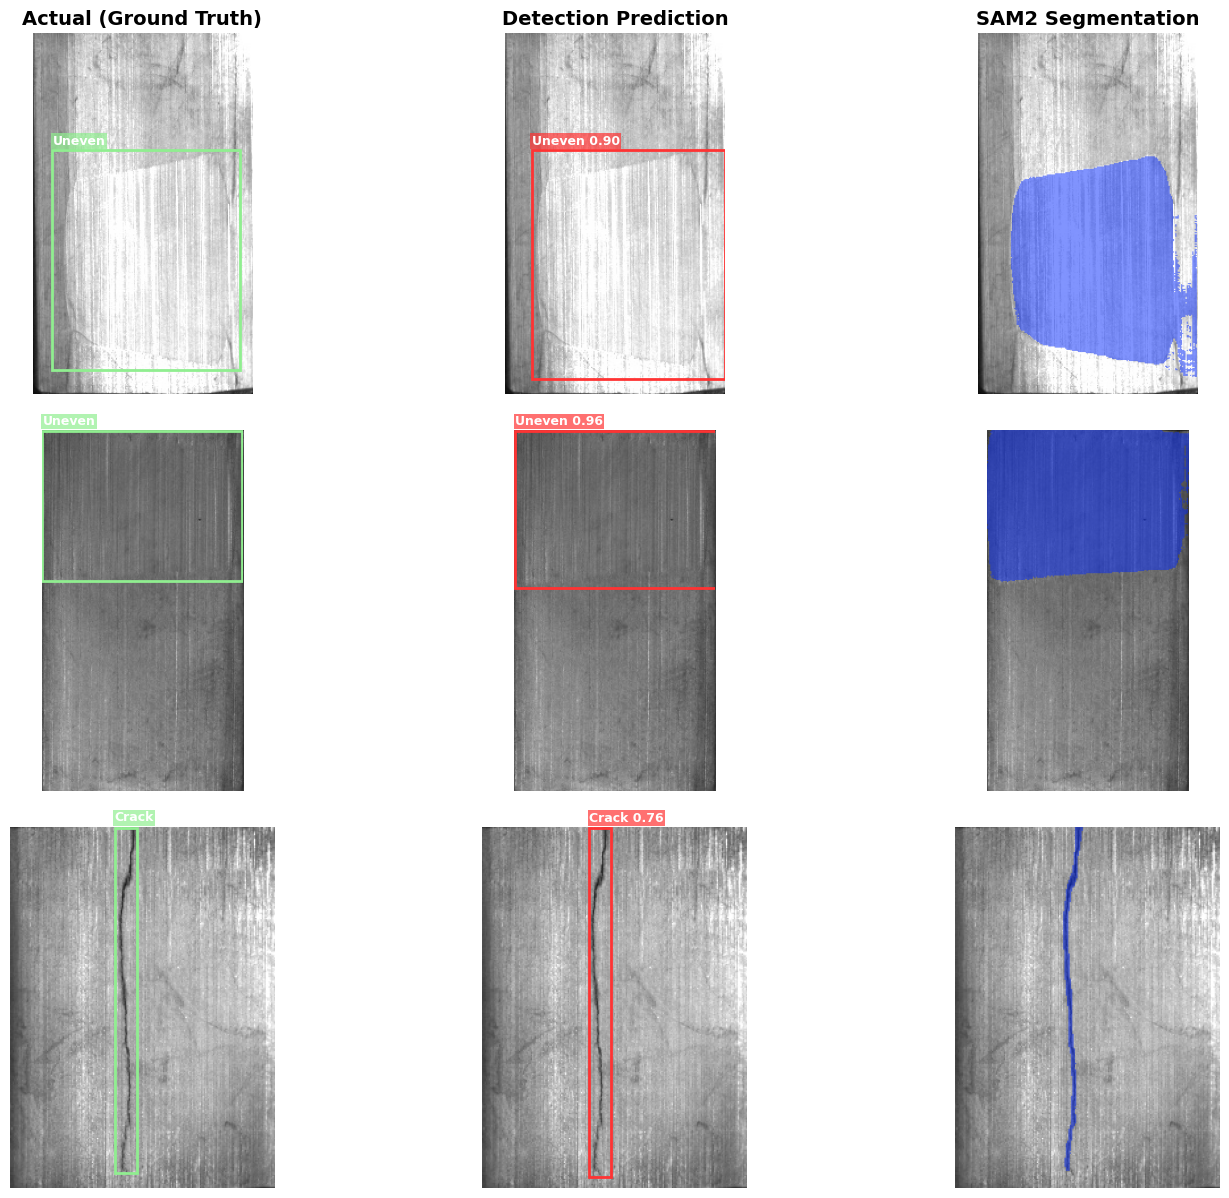

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import random
from pathlib import Path
# import torch # Optional, depending on your environment

def plot_pipeline_evaluation(detect_model, segment_model, images_dir, labels_dir, class_names, num_samples=3):
    """
    Plots a 3-column evaluation pipeline:
    1. Actual (Ground Truth)
    2. Detection Prediction (e.g., RT-DETR/YOLO)
    3. Segmentation (SAM2, prompted by detection boxes)
    """
    
    # 1. Filter images (Only keep images with defect classes 0-4)
    img_paths = sorted(list(Path(images_dir).glob("*.jpg")))
    valid_images = []

    print("Filtering images...")
    for img_path in img_paths:
        label_path = Path(labels_dir) / f"{img_path.stem}.txt"
        if not label_path.exists(): continue
        
        with open(label_path, "r") as f:
            lines = f.readlines()
            
        if not lines: continue
        
        # Check if relevant classes are present
        has_defect = False
        for line in lines:
            try:
                # Assuming classes 0-4 are defects
                if int(line.split()[0]) <= 4:
                    has_defect = True
                    break
            except ValueError: continue
            
        if has_defect:
            valid_images.append(img_path)

    print(f"Found {len(valid_images)} relevant images.")

    # 2. Select random samples
    if not valid_images:
        print("No valid images found.")
        return
        
    selected_images = random.sample(valid_images, min(len(valid_images), num_samples))

    # 3. Setup Plot
    # 'gridspec_kw' with small wspace/hspace reduces the gap between subplots
    fig, axes = plt.subplots(
        len(selected_images), 3, 
        figsize=(18, 5 * len(selected_images)),
        gridspec_kw={'wspace': 0.05, 'hspace': 0.1} 
    )
    
    # Handle single image case (ensure axes is always a 2D array)
    if len(selected_images) == 1: 
        axes = [axes] 

    for i, img_path in enumerate(selected_images):
        # Load image as RGB
        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        
        # Select axes for the current row
        ax_gt = axes[i][0] if len(selected_images) > 1 else axes[0]
        ax_det = axes[i][1] if len(selected_images) > 1 else axes[1]
        ax_seg = axes[i][2] if len(selected_images) > 1 else axes[2]

        # -----------------------------
        # COLUMN 1: Ground Truth (Actual)
        # -----------------------------
        ax_gt.imshow(img)
        # Only set title for the first row to save space
        if i == 0: ax_gt.set_title("Actual (Ground Truth)", fontsize=14, fontweight='bold')
        ax_gt.axis("off")
        
        label_path = Path(labels_dir) / f"{img_path.stem}.txt"
        if label_path.exists():
            with open(label_path, "r") as f:
                lines = f.readlines()
                for line in lines:
                    data = list(map(float, line.split()))
                    cls_id = int(data[0])
                    if cls_id > 4: continue

                    # YOLO format: center_x, center_y, width, height (normalized)
                    xc, yc, bw, bh = data[1], data[2], data[3], data[4]
                    x1, y1 = (xc - bw/2)*w, (yc - bh/2)*h
                    
                    # Draw Green Box for Ground Truth
                    rect = patches.Rectangle(
                        (x1, y1), bw*w, bh*h, 
                        linewidth=2, edgecolor="lightgreen", facecolor="none"
                    )
                    ax_gt.add_patch(rect)
                    
                    # Add Label
                    name = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
                    ax_gt.text(
                        x1, y1-5, name, 
                        color='white', fontweight='bold', fontsize=9,
                        bbox=dict(facecolor='lightgreen', edgecolor='none', alpha=0.7, pad=1)
                    )

        # -----------------------------
        # COLUMN 2: Detection Prediction
        # -----------------------------
        # Run Inference
        det_results = detect_model(str(img_path), verbose=False)[0]
        
        ax_det.imshow(img)
        if i == 0: ax_det.set_title("Detection Prediction", fontsize=14, fontweight='bold')
        ax_det.axis("off")
        
        pred_boxes = [] # Store boxes for SAM2 prompting
        
        if det_results.boxes:
            for box in det_results.boxes:
                cls_id = int(box.cls[0].item())
                # Filter classes 0-4
                if cls_id > 4: continue
                
                # Get coordinates (xyxy)
                coords = box.xyxy[0].cpu().numpy()
                x1, y1, x2, y2 = coords
                pred_boxes.append(coords) 
                
                # Draw Red Box for Prediction
                rect = patches.Rectangle(
                    (x1, y1), x2-x1, y2-y1, 
                    linewidth=2, edgecolor="#FF3333", facecolor="none"
                )
                ax_det.add_patch(rect)
                
                # Add Label with Confidence
                conf = box.conf[0].item()
                name = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
                ax_det.text(
                    x1, y1-5, f"{name} {conf:.2f}", 
                    color='white', fontweight='bold', fontsize=9,
                    bbox=dict(facecolor='#FF3333', edgecolor='none', alpha=0.7, pad=1)
                )

        # -----------------------------
        # COLUMN 3: Segmentation (SAM2)
        # -----------------------------
        if i == 0: ax_seg.set_title("SAM2 Segmentation", fontsize=14, fontweight='bold')
        ax_seg.axis("off")

        if pred_boxes:
            # Feed detected boxes as prompts to SAM2
            seg_results = segment_model(str(img_path), bboxes=pred_boxes, verbose=False)[0]
            
            # Plot results (boxes=False to show only masks)
            # [..., ::-1] converts BGR to RGB for correct color display
            res_plotted = seg_results.plot(boxes=False, probs=False) 
            ax_seg.imshow(res_plotted[..., ::-1]) 
        else:
            # Fallback if no defects detected
            ax_seg.imshow(img)
            ax_seg.text(
                w/2, h/2, "No Defects Detected", 
                color='gray', ha='center', va='center', fontweight='bold'
            )

    # Final layout adjustment
    # tight_layout works well with gridspec_kw defined above
    plt.tight_layout()
    plt.show()

plot_pipeline_evaluation(model, sam_model, TEST_IMAGES_DIR, TEST_LABELS_DIR, class_names, num_samples=3)